# Exploratory Data Analysis — AerialWaste v3

**Dataset**: AerialWaste v3 (Zenodo DOI: 10.5281/zenodo.7034382)  
**Paper**: Torres & Fraternali, *Scientific Data* 10, 63 (2023)  
**Baseline**: Gibellini et al., *Waste Management Bulletin* 3 (2025), arXiv:2502.06607  

This notebook produces:
1. Class distribution bar charts (binary and 22-class)
2. Sample image grid per class (4×4)
3. Per-channel RGB histograms
4. Correlation between metadata (source, GSD) and class label
5. Analysis of class imbalance and implications for training

In [1]:
import json
import sys
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

# Ensure src is importable
sys.path.insert(0, str(Path.cwd().parent / "src"))

plt.rcParams.update({
    "figure.figsize": (12, 6),
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

SEED = 42
rng = np.random.default_rng(SEED)

In [2]:
# Load dataset metadata
DATA_ROOT = Path("../data/raw")
STATS_PATH = Path("../data/processed/dataset_stats.json")
IMAGES_DIR = DATA_ROOT / "images"
HAS_IMAGES = IMAGES_DIR.exists() and any(IMAGES_DIR.iterdir()) if IMAGES_DIR.exists() else False

def load_metadata(split: str) -> tuple[list[dict], dict[int, str]]:
    json_name = "training.json" if split == "train" else "testing.json"
    with open(DATA_ROOT / json_name) as f:
        data = json.load(f)
    # Build category ID→name mapping
    cat_map = {}
    if isinstance(data, dict) and "categories" in data:
        for c in data["categories"]:
            cat_map[c["id"]] = c["name"]
    items = data.get("images", data) if isinstance(data, dict) else data
    return items, cat_map

train_items, cat_map = load_metadata("train")
test_items, _ = load_metadata("test")
all_items = train_items + test_items

print(f"Train: {len(train_items)} | Test: {len(test_items)} | Total: {len(all_items)}")
print(f"Images available: {HAS_IMAGES}")
print(f"Category mapping: {len(cat_map)} categories")

Train: 7829 | Test: 2605 | Total: 10434
Images available: False
Category mapping: 22 categories


In [3]:
# Build DataFrame from metadata — use img_source field from JSON
SOURCE_GSD = {"AGEA": 20, "WV3": 30, "GE": 50}

def items_to_df(items: list[dict], split_name: str) -> pd.DataFrame:
    records = []
    for it in items:
        source = it.get("img_source", "Unknown")
        gsd = SOURCE_GSD.get(source)
        
        # Categories are integer IDs in the JSON
        cat_names = [cat_map.get(c, f"id_{c}") for c in it.get("categories", [])]
        
        records.append({
            "file_name": it["file_name"],
            "split": split_name,
            "label": it.get("is_candidate_location", 0),
            "label_str": "waste" if it.get("is_candidate_location", 0) == 1 else "no_waste",
            "width": it.get("width"),
            "height": it.get("height"),
            "source": source,
            "gsd_cm": gsd,
            "evidence": it.get("evidence"),
            "severity": it.get("severity"),
            "site_type": it.get("site_type"),
            "categories": cat_names,
            "n_categories": len(cat_names),
        })
    return pd.DataFrame(records)

df_train = items_to_df(train_items, "train")
df_test = items_to_df(test_items, "test")
df = pd.concat([df_train, df_test], ignore_index=True)
print(f"DataFrame: {len(df)} rows, {len(df.columns)} columns")
print(f"Sources: {df['source'].value_counts().to_dict()}")
df.head()

DataFrame: 10434 rows, 13 columns
Sources: {'GE': 6750, 'AGEA': 3450, 'WV3': 234}


,file_name,split,label,label_str,width,height,source,gsd_cm,evidence,severity,site_type,categories,n_categories
0,3456.png,train,1,waste,1055,1046,AGEA,20,n/s,n/s,n/s,[Rubble/excavated earth and rocks],1
1,2423.png,train,1,waste,697,698,WV3,30,2,1,Degraded area,"[Rubble/excavated earth and rocks, Bulky items...",3
2,3245.png,train,1,waste,1036,1065,AGEA,20,3,n/s,n/s,[],0
3,3330.png,train,1,waste,1038,1063,AGEA,20,1,n/s,n/s,[],0
4,2957.png,train,1,waste,1044,1058,AGEA,20,2,n/s,n/s,[],0


## 1. Binary Class Distribution

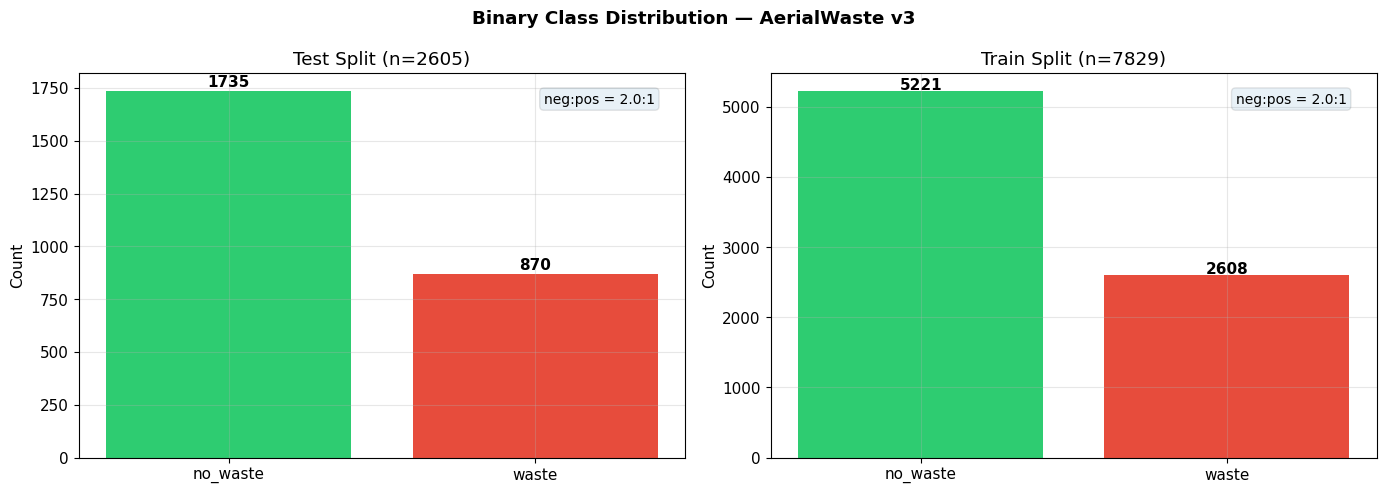

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per-split distribution
for ax, (split_name, split_df) in zip(axes, df.groupby("split")):
    counts = split_df["label_str"].value_counts()
    bars = ax.bar(counts.index, counts.values, color=["#2ecc71", "#e74c3c"])
    ax.set_title(f"{split_name.capitalize()} Split (n={len(split_df)})")
    ax.set_ylabel("Count")
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(val), ha="center", fontweight="bold")
    ratio = counts.get("no_waste", 0) / max(counts.get("waste", 0), 1)
    ax.text(0.95, 0.95, f"neg:pos = {ratio:.1f}:1",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=10, bbox=dict(boxstyle="round", alpha=0.1))

plt.suptitle("Binary Class Distribution — AerialWaste v3", fontweight="bold")
plt.tight_layout()
plt.savefig("../data/processed/binary_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Multi-class (22 Waste Categories) Distribution

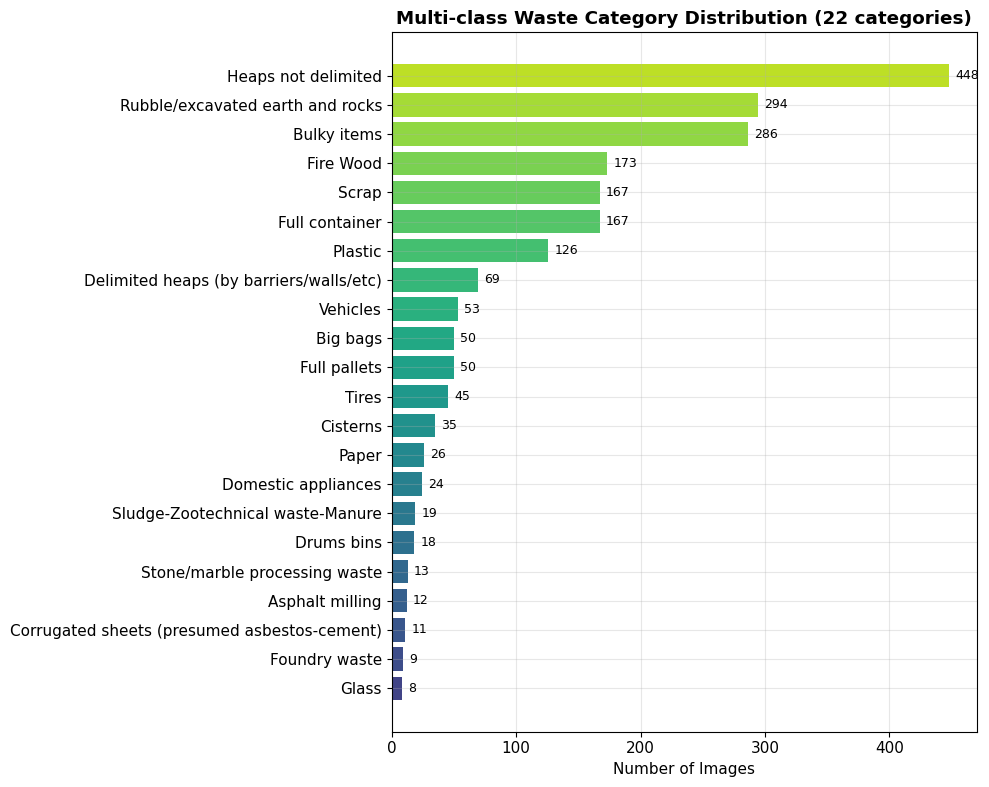


Total annotated categories: 22
Top 5 most frequent: [('Heaps not delimited', 448), ('Rubble/excavated earth and rocks', 294), ('Bulky items', 286), ('Fire Wood', 173), ('Full container', 167)]
Bottom 5 least frequent: [('Stone/marble processing waste', 13), ('Asphalt milling', 12), ('Corrugated sheets (presumed asbestos-cement)', 11), ('Foundry waste', 9), ('Glass', 8)]


In [5]:
# Flatten categories across all positive samples
all_cats = []
for cats in df["categories"]:
    all_cats.extend(cats)

cat_counts = Counter(all_cats)
cat_df = pd.DataFrame(cat_counts.items(), columns=["category", "count"]).sort_values("count", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(cat_df)))
bars = ax.barh(cat_df["category"], cat_df["count"], color=colors)
ax.set_xlabel("Number of Images")
ax.set_title("Multi-class Waste Category Distribution (22 categories)", fontweight="bold")

# Annotate counts
for bar, val in zip(bars, cat_df["count"]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../data/processed/multiclass_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTotal annotated categories: {len(cat_counts)}")
print(f"Top 5 most frequent: {cat_counts.most_common(5)}")
print(f"Bottom 5 least frequent: {cat_counts.most_common()[-5:]}")

## 3. Sample Image Grid (4×4 per class)

In [6]:
if HAS_IMAGES:
    def plot_image_grid(df_subset: pd.DataFrame, title: str, n_rows: int = 4, n_cols: int = 4):
        """Plot a grid of sample images."""
        samples = df_subset.sample(n=min(n_rows * n_cols, len(df_subset)), random_state=SEED)
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 16))
        for idx, (ax, (_, row)) in enumerate(zip(axes.flat, samples.iterrows())):
            img_path = IMAGES_DIR / row["file_name"]
            if img_path.exists():
                img = Image.open(img_path)
                ax.imshow(img)
            ax.set_title(f"{row['source']} | {row['gsd_cm']}cm", fontsize=8)
            ax.axis("off")
        for ax in axes.flat[len(samples):]:
            ax.axis("off")
        fig.suptitle(title, fontweight="bold", fontsize=14)
        plt.tight_layout()
        return fig

    fig_pos = plot_image_grid(df[df["label"] == 1], "Positive Samples (Waste)")
    fig_pos.savefig("../data/processed/sample_grid_waste.png", dpi=150, bbox_inches="tight")
    plt.show()

    fig_neg = plot_image_grid(df[df["label"] == 0], "Negative Samples (No Waste)")
    fig_neg.savefig("../data/processed/sample_grid_no_waste.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("⏭ Images not downloaded yet — skipping sample grid.")
    print("  Run: python scripts/download_data.py")

⏭ Images not downloaded yet — skipping sample grid.
  Run: python scripts/download_data.py


## 4. Per-Channel RGB Histograms

In [7]:
if HAS_IMAGES:
    N_SAMPLES = 500
    sample_df = df.sample(n=min(N_SAMPLES, len(df)), random_state=SEED)

    channel_values = {"R": [], "G": [], "B": []}
    for _, row in sample_df.iterrows():
        img_path = IMAGES_DIR / row["file_name"]
        if not img_path.exists():
            continue
        img = np.array(Image.open(img_path).convert("RGB"))
        flat = img.reshape(-1, 3)
        idx = rng.choice(len(flat), size=min(1000, len(flat)), replace=False)
        for c, name in enumerate(["R", "G", "B"]):
            channel_values[name].extend(flat[idx, c].tolist())

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    colors_rgb = ["#e74c3c", "#2ecc71", "#3498db"]
    for ax, (ch_name, values), color in zip(axes, channel_values.items(), colors_rgb):
        ax.hist(values, bins=256, range=(0, 255), color=color, alpha=0.7, density=True)
        mean_val = np.mean(values)
        ax.axvline(mean_val, color="black", linestyle="--", alpha=0.8)
        ax.set_title(f"{ch_name} channel (mean={mean_val:.1f})")
        ax.set_xlabel("Pixel value")
        ax.set_ylabel("Density")

    plt.suptitle("Per-Channel RGB Histograms (sampled from full dataset)", fontweight="bold")
    plt.tight_layout()
    plt.savefig("../data/processed/rgb_histograms.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("⏭ Images not downloaded yet — skipping RGB histograms.")
    print("  Run: python scripts/download_data.py")

⏭ Images not downloaded yet — skipping RGB histograms.
  Run: python scripts/download_data.py


## 5. Source / GSD × Class Correlation

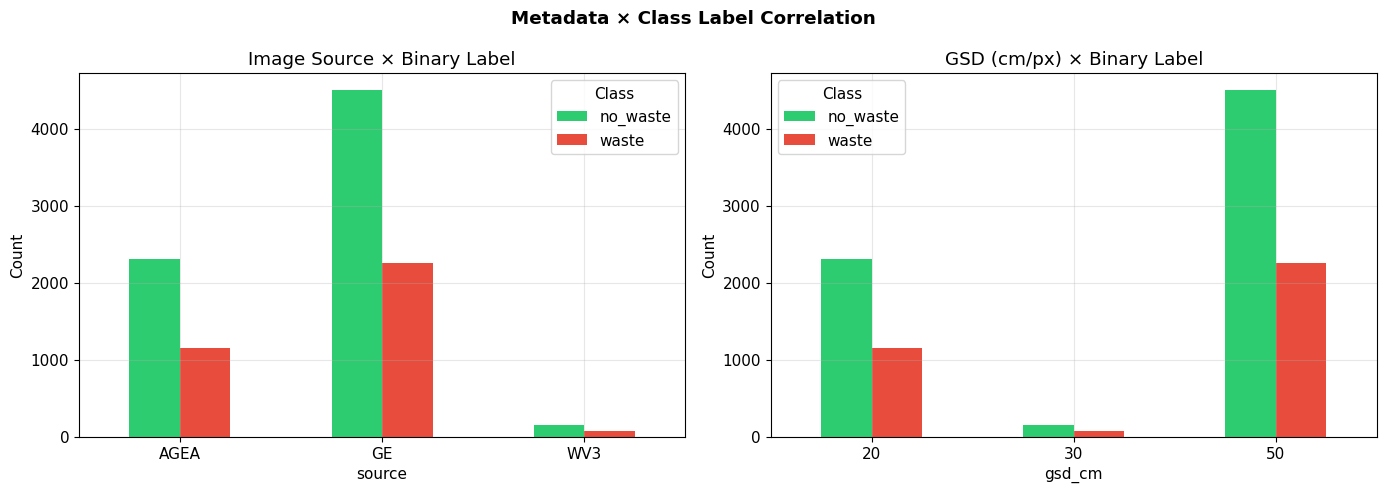

Source × Label:
label_str  no_waste  waste
source                    
AGEA           2300   1150
GE             4500   2250
WV3             156     78

GSD × Label:
label_str  no_waste  waste
gsd_cm                    
20             2300   1150
30              156     78
50             4500   2250


In [8]:
# Source distribution by class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: source × label
ct = pd.crosstab(df["source"], df["label_str"])
ct.plot(kind="bar", ax=axes[0], color=["#2ecc71", "#e74c3c"], rot=0)
axes[0].set_title("Image Source × Binary Label")
axes[0].set_ylabel("Count")
axes[0].legend(title="Class")

# GSD distribution by class
ct2 = pd.crosstab(df["gsd_cm"], df["label_str"])
ct2.plot(kind="bar", ax=axes[1], color=["#2ecc71", "#e74c3c"], rot=0)
axes[1].set_title("GSD (cm/px) × Binary Label")
axes[1].set_ylabel("Count")
axes[1].legend(title="Class")

plt.suptitle("Metadata × Class Label Correlation", fontweight="bold")
plt.tight_layout()
plt.savefig("../data/processed/source_gsd_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

# Print crosstabs
print("Source × Label:")
print(ct)
print(f"\nGSD × Label:")
print(ct2)

## 6. Class Imbalance Analysis & Training Implications

In [9]:
print("=" * 60)
print("CLASS IMBALANCE ANALYSIS")
print("=" * 60)

# Binary imbalance
n_pos = (df["label"] == 1).sum()
n_neg = (df["label"] == 0).sum()
print(f"\nBinary: {n_pos} positive ({n_pos/len(df)*100:.1f}%), "
      f"{n_neg} negative ({n_neg/len(df)*100:.1f}%)")
print(f"Negative:Positive ratio = {n_neg/n_pos:.2f}:1")
print(f"→ Designed 2:1 ratio to reflect real-world class imbalance")

# Multi-class analysis
if cat_counts:
    print(f"\n22-Class Distribution:")
    top5 = cat_counts.most_common(5)
    bot5 = cat_counts.most_common()[-5:]
    print(f"  Most frequent:")
    for name, count in top5:
        print(f"    {name}: {count}")
    print(f"  Least frequent:")
    for name, count in bot5:
        print(f"    {name}: {count}")

print(f"\n{'=' * 60}")
print("IMPLICATIONS FOR TRAINING")
print("=" * 60)
print("""
1. Binary task: The 2:1 neg:pos ratio is moderate. BCE loss without
   class weights works well (as shown by Gibellini et al., 92% F1).
   For further improvement, consider pos_weight in BCEWithLogitsLoss.

2. Multi-class task: Severe imbalance expected — some categories
   (e.g., construction_waste) are much more common than others
   (e.g., electronic_waste, glass). For multi-label training:
   - Use class-weighted BCE or focal loss
   - Consider oversampling rare categories
   - Use stratified splits preserving category proportions

3. Source bias: Different sources have different GSD and visual
   characteristics. The best model filters for AGEA (20 cm/px)
   for highest resolution. Multi-source training could improve
   generalization.
""")

CLASS IMBALANCE ANALYSIS

Binary: 3478 positive (33.3%), 6956 negative (66.7%)
Negative:Positive ratio = 2.00:1
→ Designed 2:1 ratio to reflect real-world class imbalance

22-Class Distribution:
  Most frequent:
    Heaps not delimited: 448
    Rubble/excavated earth and rocks: 294
    Bulky items: 286
    Fire Wood: 173
    Full container: 167
  Least frequent:
    Stone/marble processing waste: 13
    Asphalt milling: 12
    Corrugated sheets (presumed asbestos-cement): 11
    Foundry waste: 9
    Glass: 8

IMPLICATIONS FOR TRAINING

1. Binary task: The 2:1 neg:pos ratio is moderate. BCE loss without
   class weights works well (as shown by Gibellini et al., 92% F1).
   For further improvement, consider pos_weight in BCEWithLogitsLoss.

2. Multi-class task: Severe imbalance expected — some categories
   (e.g., construction_waste) are much more common than others
   (e.g., electronic_waste, glass). For multi-label training:
   - Use class-weighted BCE or focal loss
   - Consider overs

In [10]:
# Load and display pre-computed stats if available
if STATS_PATH.exists():
    with open(STATS_PATH) as f:
        stats = json.load(f)
    print("Pre-computed Dataset Statistics:")
    print(json.dumps(stats, indent=2))
    
    if stats.get("channel_stats") and stats["channel_stats"].get("mean"):
        mean = stats["channel_stats"]["mean"]
        std = stats["channel_stats"]["std"]
        print(f"\nNormalization values for AerialWaste:")
        print(f"  mean = [{mean[0]:.4f}, {mean[1]:.4f}, {mean[2]:.4f}]")
        print(f"  std  = [{std[0]:.4f}, {std[1]:.4f}, {std[2]:.4f}]")
else:
    print("Run 'python scripts/download_data.py' first to generate dataset_stats.json")

Pre-computed Dataset Statistics:
{
  "splits": {
    "train": {
      "total": 7829,
      "positive": 2608,
      "negative": 5221,
      "ratio_neg_pos": 2.0,
      "sources": {
        "AGEA": 2582,
        "WV3": 181,
        "GE": 5066
      },
      "category_counts": {
        "Heaps not delimited": 355,
        "Bulky items": 242,
        "Rubble/excavated earth and rocks": 228,
        "Scrap": 140,
        "Fire Wood": 135,
        "Full container": 113,
        "Plastic": 102,
        "Full pallets": 43,
        "Delimited heaps (by barriers/walls/etc)": 38,
        "Tires": 32,
        "Big bags": 31,
        "Vehicles": 27,
        "Cisterns": 26,
        "Paper": 21,
        "Domestic appliances": 19,
        "Drums bins": 16,
        "Sludge-Zootechnical waste-Manure": 15,
        "Stone/marble processing waste": 12,
        "Corrugated sheets (presumed asbestos-cement)": 10,
        "Asphalt milling": 9,
        "Foundry waste": 8,
        "Glass": 6
      }
    },
    